In [1]:
import numpy as np
import scipy as sp
import sympy as sym
import matplotlib.pyplot as plt
import DSKR_tools

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Primer: 2D konstrukcija

In [ ]:
# Struktura A - okvir

# podatki
L1 = 1 # m
L2 = 1.5 # m
h = 0.030 # m

ρ_A = 2700 # kg /m3
E_A = 70e9 # Pa

A_A = h*h # m^2
I_A = h*h**3/12 # m^4

# osnovna geometrija
vozlisca_osn_A = np.array([[0,0],[0,L1],[L2,L1]])
elementi_osn_A = np.array([[0,1],[1,2]])

# Struktura B - paličje

# podatki
L3 = 1.5 # m
phi = np.pi/10 # rad
d = 0.01 # m

ρ_B = 7800 # kg /m3
E_B = 210e9 # Pa
A_B = np.pi * d**2 / 4 # m^2

# osnovna geometrija
vozlisca_B = np.array([[L2,0],[L2+L3,0],[L2,L1]])
elementi_B = np.array([[0,1],[1,2],[2,0]])

### Definicija objektov

In [86]:
frame = DSKR_tools.Frame2D(vozlisca_osn_A, elementi_osn_A, A_A, E_A, I_A, ρ_A, n_mesh=7) # zgostitev mreže
truss = DSKR_tools.Truss2D(vozlisca_B, elementi_B, A_B, E_B, ρ_B)

Generated a mesh with 15 nodes and 14 elements.
Solver has been updated.
Solver has been updated.


### Prikaz obeh konstrukcij

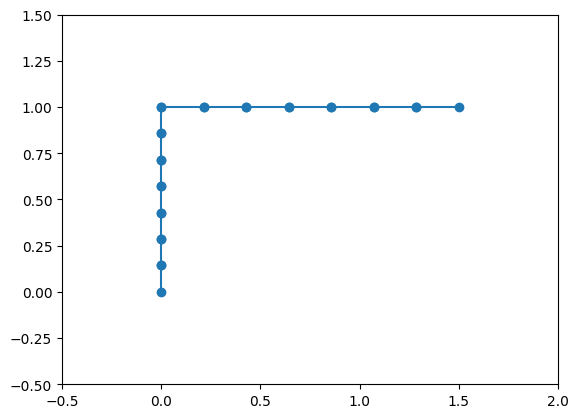

In [87]:
frame.display()

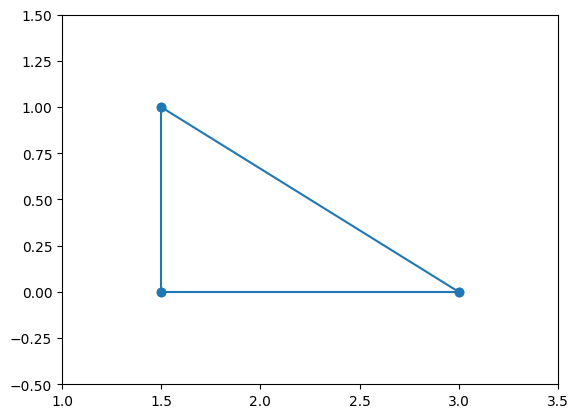

In [88]:
truss.display()

### Dodajanje podpor

In [89]:
frame.edit_constraints()
truss.edit_constraints()

Solver has been updated.
Solver has been updated.
Solver has been updated.
Solver has been updated.


### Prikaz posameznih lastnih oblik

In [ ]:
frame.animate_mode_shapes()
truss.animate_mode_shapes()
frame.eig_freq[:5], truss.eig_freq


KONTROLE: [Preslednica] Start/Stop | [A/D] ali [<- / ->] Menjava načina | [Q] Izhod

Mode: 0 | Freq: 5.11 Hz
Animacija končana.
Način: 0 | Frekvenca: 0.00 Hz

(array([5.1050000e+00, 1.4972000e+01, 5.6770000e+01, 1.3092600e+02,
        1.8329100e+02, 3.3412000e+02, 4.1203400e+02, 5.8735900e+02,
        7.8184200e+02, 9.0210200e+02, 1.1660950e+03, 1.2723930e+03,
        1.3767980e+03, 1.6641240e+03, 1.8549190e+03, 2.0768080e+03,
        2.4487640e+03, 2.8445260e+03, 3.1759970e+03, 3.4281580e+03,
        3.7047130e+03, 4.0601330e+03, 4.3868920e+03, 5.1318950e+03,
        5.3088440e+03, 5.7784660e+03, 6.2709020e+03, 6.7886180e+03,
        7.1075600e+03, 7.6235730e+03, 8.4615410e+03, 9.1517010e+03,
        9.3852920e+03, 9.9045400e+03, 1.0780356e+04, 1.1708071e+04,
        1.2744449e+04, 1.3009515e+04, 1.3653800e+04, 1.5879667e+04,
        1.6513911e+04, 1.8779064e+04]),
 array([   0.   ,    0.   ,  660.528, 1162.741, 1421.286]))

### Združimo paličji

In [92]:
combined = DSKR_tools.Combine2D(frame, truss)

In [ ]:
combined.animate_mode_shapes()


KONTROLE: [Preslednica] Start/Stop | [A/D] ali [<- / ->] Menjava načina | [Q] Izhod                                                 

Mode: 12 | Freq: 1134.32 Hz                                    
Animacija končana.


# Primer: 3D konstrukcija

In [2]:
# podatki
ρ = 2700 # kg/m3
E = 70e9 # Pa
L = 1 # m

b = 0.030 # m
h = 0.015 # m
A = b*h # m^2
G = 23.6e9
J = 2.31e-8
Iz = b*h**3/12 # m^4
Iy = h*b**3/12 # m^4

In [ ]:
import numpy as np

# ─── VOZLIŠČA ───────────────────────────────────────────────
vozlisca_vse = np.array([
    # Spodnji pas (z=0)
    [0,  0, 0], [3,  0, 0], [6,  0, 0], [9,  0, 0], [12,  0, 0],  # 0–4
    [0,  3, 0], [3,  3, 0], [6,  3, 0], [9,  3, 0], [12,  3, 0],  # 5–9
    # Zgornji pas (z=3)
    [1.5, 0, 3], [4.5, 0, 3], [7.5, 0, 3], [10.5, 0, 3],          # 10–13
    [1.5, 3, 3], [4.5, 3, 3], [7.5, 3, 3], [10.5, 3, 3],          # 14–17
])

vozlisca_frame = np.array([
    # Spodnji pas (z=0)
    [0,  0, 0], [3,  0, 0], [6,  0, 0], [9,  0, 0], [12,  0, 0],  # 0–4
    [0,  3, 0], [3,  3, 0], [6,  3, 0], [9,  3, 0], [12,  3, 0],  # 5–9
])
vozlisca_truss = vozlisca_vse


elementi_frame = np.array([
    # X-smer, y=0 vrsta
    [0, 1], [1, 2], [2, 3], [3, 4],
    # X-smer, y=1 vrsta
    [5, 6], [6, 7], [7, 8], [8, 9],
    # Y-smer (prečniki)
    [0, 5], [1, 6], [2, 7], [3, 8], [4, 9],
])

elementi_truss = np.array([
    # Zgornji pas X, y=0 vrsta
    [10, 11], [11, 12], [12, 13],
    # Zgornji pas X, y=1 vrsta
    [14, 15], [15, 16], [16, 17],
    # Zgornji pas Y (prečniki)
    [10, 14], [11, 15], [12, 16], [13, 17],

    # Krajni vertikali (n0→t10, n5→t14)
    [0, 10], [5, 14],
    # Krajni vertikali (n4→t13, n9→t17)
    [4, 13], [9, 17],

    # Diagonale + vertikale (Pratt: natezne diagonale navzven od sredine)
    # Polje 1 (med x=0 in x=3): n1-t10, n1-t11  |  n6-t14, n6-t15
    [1, 10], [1, 11],
    [6, 14], [6, 15],
    # Polje 2 (med x=3 in x=6): n2-t11, n2-t12  |  n7-t15, n7-t16
    [2, 11], [2, 12],
    [7, 15], [7, 16],
    # Polje 3 (med x=6 in x=9): n3-t12, n3-t13  |  n8-t16, n8-t17
    [3, 12], [3, 13],
    [8, 16], [8, 17],
])

### Definiramo objekte v 3D

In [4]:
# uvoz matrike podpor za Frame3D objekt
import pickle
with open('pratt_constraints_3D.pkl', 'rb') as f:
    matrika_podpor = pickle.load(f)

In [5]:
palicje = DSKR_tools.Truss3D(vozlisca_truss, elementi_truss, A, E , ρ)
okvir = DSKR_tools.Frame3D(vozlisca_frame, elementi_frame, A, E, G, Iy, Iz, J, ρ, constraints=matrika_podpor, n_mesh=20) # zgostitev mreže na 20 mora bit, da podpore pravilno uvozimo

Solver has been updated.
3D Mesh: 257 nodes, 260 elements.
Solver has been updated.


### Prikaz obeh konstrukcij

In [6]:
palicje.display()
okvir.display()

In [7]:
zdruzena = DSKR_tools.Combine3D(palicje, okvir)

### Prikažemo lastne oblike

In [8]:
zdruzena.animate_mode_shapes()

C:\Users\david\Documents\faks_MAG\Dinamika strojev in konstrukcij\DSKR_tools\DSKR_tools\combine.py:440: ComplexWarning: Casting complex values to real discards the imaginary part
  line_set_deformed.points = o3d.utility.Vector3dVector(deformed_pts)
C:\Users\david\Documents\faks_MAG\Dinamika strojev in konstrukcij\DSKR_tools\DSKR_tools\combine.py:441: ComplexWarning: Casting complex values to real discards the imaginary part
  points_cloud.points = o3d.utility.Vector3dVector(deformed_pts)


Mode: 52 | Freq: 44.78 Hz

### Lastne frekvence združene konstrukcije

In [11]:
zdruzena.eig_freq[:10]

array([0.   , 0.   , 0.   , 0.   , 1.098, 2.365, 3.581, 4.228, 4.489,
       4.921])